# BNS GRB Classification

Classifying Binary Neutron Star mergers from the COMPAS fiducial population (Model A) using the [Gottlieb et al. (2023)](https://arxiv.org/abs/2309.00038) hybrid scenario.

**Classification rules (BNS):**
- `M_tot < 2.8 M☉` → Short cbGRB (HMNS collapse)
- `M_tot ≥ 2.8 M☉` and `q < 1.2` → Short cbGRB (BH + light disk)
- `M_tot ≥ 2.8 M☉` and `q ≥ 1.2` → Long cbGRB (BH + massive disk, GW211211A-like)

**Mass-ratio convention:** $q = M_{\max}/M_{\min} \ge 1$, consistent with Gottlieb et al. (2023) Figure 2.

**Data:** COMPAS fiducial BNS simulation - [Zenodo 5189849](https://zenodo.org/records/5189849)

## 1. Load Data

In [2]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

path = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5'

fdata = h5.File(path, 'r')
fDCO  = fdata['doubleCompactObjects']

mass1               = fDCO['M1'][...].squeeze()
mass2               = fDCO['M2'][...].squeeze()
weights             = fDCO['weight'][...].squeeze()
metallicitySystems  = fDCO['Metallicity1'][...].squeeze()
mergesInHubbleTime  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
tc                  = fDCO['tc'][...].squeeze()
tform               = fDCO['tform'][...].squeeze()
m1zams              = fDCO['M1ZAMS'][...].squeeze()
m2zams              = fDCO['M2ZAMS'][...].squeeze()

## 2. Gottlieb GRB Classification

Compute total mass `M_tot` and mass ratio `q` for all merging BNS systems, then assign a GRB class following the **Gottlieb et al. (2023)** hybrid scenario [arXiv:2309.00038].

**Key assumptions:**
- `M_crit = 2.8 M☉` (total mass threshold for prompt collapse; consistent with GW170817, $R_{1.4} \sim 12.5$ km → $M_{\rm crit} \sim 2.81\,M_\odot$).
- `q_threshold = 1.2` (mass-ratio boundary between "light disk" Short Type II and "massive disk" Long cbGRB for prompt-collapse remnants), from Gottlieb et al. (2023) Fig. 2.
- **100% GRB efficiency (fiducial):** Every BNS merger is assigned a GRB class (Short Type I, Short Type II, or Long). There is no "No GRB" category. This is controlled by the `epsilon_grb_BNS` parameter in the rate notebook (`GRB_CosmicRate`), where fiducial = 1.0 and physically motivated values of 0.5 to 0.8 account for disk evaporation, jet breakout failure, and short-lived HMNS that collapse before jet launch (Gottlieb et al. 2023, Sec. 4.3). The BNS rate scales linearly with this parameter.
- **Scenario choice:** We adopt the Gottlieb et al. (2023) **hybrid** scenario (their Fig. 2, right panel). In this framework, prompt-collapse systems ($M_{\rm tot} \geq M_{\rm crit}$) are sub-divided by mass ratio: $q < q_{\rm thresh}$ produces a BH + light disk (Short Type II), while $q \geq q_{\rm thresh}$ yields a BH + massive tidal tail producing a Long cbGRB. The alternative "all-BH" scenario (Fig. 2, left panel) assigns all prompt-collapse remnants to a single Short cbGRB channel, which would eliminate the Long cbGRB pathway for BNS mergers entirely.
- **No SMNS / stable NS category:** Systems with $M_{\rm tot} \ll M_{\rm crit}$ may form supramassive or stable NS remnants rather than HMNS. These could power different emission (e.g., magnetar plateaux) and are not separately modelled here.

In [3]:
mask_merging = (mergesInHubbleTime == 1)

M_tot = mass1[mask_merging] + mass2[mask_merging]
q     = np.maximum(mass1[mask_merging], mass2[mask_merging]) / \
        np.minimum(mass1[mask_merging], mass2[mask_merging])

M_crit = 2.8

short_typeI  = (M_tot < M_crit)                          # HMNS remnant powers jet
short_typeII = (M_tot >= M_crit) & (q < 1.2)             # BH + light disk
short_cbGRB  = short_typeI | short_typeII                 # combined (kept for backward compat)
long_cbGRB   = (M_tot >= M_crit) & (q >= 1.2)            # BH + massive disk

### Sanity Check

In [4]:
n_merging    = mask_merging.sum()
n_short_I    = short_typeI.sum()
n_short_II   = short_typeII.sum()
n_short      = short_cbGRB.sum()
n_long       = long_cbGRB.sum()

print(f"Total BNS systems:       {len(mass1):,}")
print(f"Merging in Hubble time:  {n_merging:,}  ({100*n_merging/len(mass1):.1f}%)")
print(f"Short Type I  (HMNS):    {n_short_I:,}  ({100*n_short_I/n_merging:.1f}%)")
print(f"Short Type II (BH+disk): {n_short_II:,}  ({100*n_short_II/n_merging:.1f}%)")
print(f"Short cbGRB (combined):  {n_short:,}  ({100*n_short/n_merging:.1f}%)")
print(f"Long cbGRB:              {n_long:,}  ({100*n_long/n_merging:.1f}%)")
print(f"\nM_tot range: {M_tot.min():.2f} to {M_tot.max():.2f} M☉")
print(f"q range:     {q.min():.2f} to {q.max():.2f}")

Total BNS systems:       233,137
Merging in Hubble time:  233,137  (100.0%)
Short Type I  (HMNS):    160,646  (68.9%)
Short Type II (BH+disk): 29,209  (12.5%)
Short cbGRB (combined):  189,855  (81.4%)
Long cbGRB:              43,282  (18.6%)

M_tot range: 2.54 – 4.96 M☉
q range:     1.00 – 1.96


## 3. M₁ vs M₂ Mass Plane

Scatter plot of final NS masses colored by GRB class. Masses are sorted so $M_1 \geq M_2$, ensuring the $q = 1.2$ boundary line correctly separates the Long cbGRB region. GW170817 ($M_1 \approx 1.46\,M_\odot$, $M_2 \approx 1.27\,M_\odot$; Abbott et al. 2019) is marked for reference.

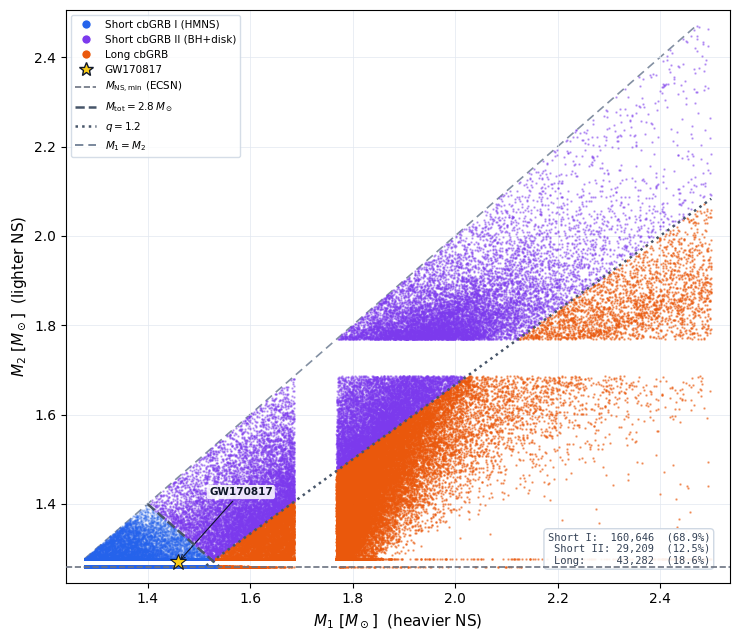

In [11]:
from matplotlib.lines import Line2D

w = weights[mask_merging]
_m1_raw = mass1[mask_merging]
_m2_raw = mass2[mask_merging]

# Enforce M1 >= M2 so the q=1.2 boundary is unambiguous
m1 = np.maximum(_m1_raw, _m2_raw)
m2 = np.minimum(_m1_raw, _m2_raw)

ecsn_floor = m2.min()

fig, ax = plt.subplots(figsize=(7.5, 6.5))

ax.scatter(m1[short_typeI],  m2[short_typeI],
           s=0.6, alpha=0.25, color='#2563EB', rasterized=True, zorder=1)
ax.scatter(m1[short_typeII], m2[short_typeII],
           s=0.6, alpha=0.40, color='#7C3AED', rasterized=True, zorder=2)
ax.scatter(m1[long_cbGRB],   m2[long_cbGRB],
           s=0.6, alpha=0.50, color='#EA580C', rasterized=True, zorder=3)

# ECSN floor reference line (horizontal only; vertical is now the equal-mass diagonal)
ax.axhline(ecsn_floor, color='#6B7280', lw=1.2, ls='--', zorder=5)

# Classification boundaries, clipped to data range
_x0, _x1 = m1.min(), m1.max()
_y0, _y1 = ecsn_floor, m2.max()
_m = np.linspace(_x0, _x1, 300)

# M_tot = 2.8 M_sun: M2 = 2.8 - M1
_mtot_line = 2.8 - _m
_mask_mt = (_mtot_line >= _y0) & (_mtot_line <= _m)
ax.plot(_m[_mask_mt], _mtot_line[_mask_mt],
        color='#475569', lw=1.8, ls='--', zorder=4)

# q = 1.2: M2 = M1/1.2 (valid when M1 >= M2, i.e. below the diagonal)
_q_line = _m / 1.2
_mask_q = (_q_line >= _y0) & (_q_line <= _m)
ax.plot(_m[_mask_q], _q_line[_mask_q],
        color='#475569', lw=1.8, ls=':', zorder=4)

# M1 = M2 diagonal (upper boundary for sorted masses)
ax.plot([max(_x0, _y0), min(_x1, _y1)], [max(_x0, _y0), min(_x1, _y1)],
        color='#64748B', lw=1.2, ls=(0, (5, 3)), alpha=0.8, zorder=0)

# GW170817 reference (Abbott et al. 2017, 2019; 90% credible region midpoints)
ax.plot(1.46, 1.27, marker='*', ms=12, mec='#0F172A', mfc='#FACC15',
        mew=0.8, zorder=10)
ax.annotate('GW170817', xy=(1.46, 1.27), xytext=(1.52, 1.42),
            fontsize=7.5, color='#0F172A', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#0F172A', lw=0.8),
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='none', alpha=0.85))

# Count / fraction annotations (matches BHNS panel style)
n_tot  = len(m1)
n_sI   = short_typeI.sum()
n_sII  = short_typeII.sum()
n_long = long_cbGRB.sum()
ax.text(0.97, 0.03,
        f'Short I:  {n_sI:,}  ({100*n_sI/n_tot:.1f}%)\n'
        f'Short II: {n_sII:,}  ({100*n_sII/n_tot:.1f}%)\n'
        f'Long:     {n_long:,}  ({100*n_long/n_tot:.1f}%)',
        transform=ax.transAxes, fontsize=7.5, family='monospace',
        color='#334155', ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor='#CBD5E1', alpha=0.92))


# Axes
_pad_x = 0.03 * (_x1 - _x0)
_pad_y = 0.03 * (_y1 - _y0)
ax.set_xlim(_x0 - _pad_x, _x1 + _pad_x)
ax.set_ylim(_y0 - _pad_y, _y1 + _pad_y)

ax.set_xlabel(r'$M_1\ [M_\odot]$  (heavier NS)', fontsize=11)
ax.set_ylabel(r'$M_2\ [M_\odot]$  (lighter NS)',  fontsize=11)

ax.grid(which='major', color='#E2E8F0', linewidth=0.5, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2563EB',
           markersize=7, label='Short cbGRB I (HMNS)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#7C3AED',
           markersize=7, label='Short cbGRB II (BH+disk)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C',
           markersize=7, label='Long cbGRB'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='#FACC15',
           markeredgecolor='#0F172A', markersize=10, label='GW170817'),
    Line2D([0],[0], color='#6B7280', lw=1.2, ls='--',
           label=r'$M_\mathrm{NS,min}$ (ECSN)'),
    Line2D([0],[0], color='#475569', lw=1.8, ls='--',
           label=r'$M_\mathrm{tot} = 2.8\,M_\odot$'),
    Line2D([0],[0], color='#475569', lw=1.8, ls=':',
           label=r'$q = 1.2$'),
    Line2D([0],[0], color='#64748B', lw=1.2, ls=(0, (5, 3)),
           label=r'$M_1 = M_2$'),
], fontsize=7.5, loc='upper left', frameon=True, fancybox=True,
   edgecolor='#CBD5E1')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_mass_plane.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 4. Formation Efficiency vs Metallicity

Formation efficiency $\eta(Z) = \sum_i w_i / \langle M_{\rm evolved}\rangle$ [mergers per $M_\odot$], where $w_i$ are STROOPWAFEL sampling weights and $\langle M_{\rm evolved}\rangle = 77{,}708{,}655\,M_\odot$ is the total stellar mass evolved per metallicity bin in the COMPAS simulation (Model A, Kroupa IMF, primary mass range 5 to 150 $M_\odot$; Zenodo 5189849). Computed at each of the 53 metallicity grid points ($Z \in [0.0001, 0.03]$).

**Note:** The dip/recovery around $Z \sim 0.005$ to $0.01$ is a known artifact of the COMPAS $\lambda$ prescription for common-envelope binding energy, which bifurcates near $Z \approx 0.0105$ (Broekgaarden et al. 2022, Fig. 1). It is not a physical feature. The overall BNS yield of $\sim 10^{-6}\,M_\odot^{-1}$, approximately flat across metallicity, is consistent with Neijssel et al. (2019) Fig. 1 and Broekgaarden et al. (2022).

In [13]:
metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

meanMassEvolved = 77708655  # M_sun; see GRB_CosmicRate.ipynb Section 5 for derivation

Z_all   = metallicitySystems[mask_merging]
w_all   = weights[mask_merging]

eff_total    = np.zeros(len(metallicityGrid))
eff_short    = np.zeros(len(metallicityGrid))
eff_short_I  = np.zeros(len(metallicityGrid))
eff_short_II = np.zeros(len(metallicityGrid))
eff_long     = np.zeros(len(metallicityGrid))

unique_Z = np.unique(metallicitySystems)

for i, Z in enumerate(metallicityGrid):
    if Z in unique_Z:
        maskZ = (Z_all == Z)
        eff_total[i]    = np.sum(w_all[maskZ])                    / meanMassEvolved
        eff_short[i]    = np.sum(w_all[maskZ & short_cbGRB])      / meanMassEvolved
        eff_short_I[i]  = np.sum(w_all[maskZ & short_typeI])      / meanMassEvolved
        eff_short_II[i] = np.sum(w_all[maskZ & short_typeII])     / meanMassEvolved
        eff_long[i]     = np.sum(w_all[maskZ & long_cbGRB])       / meanMassEvolved

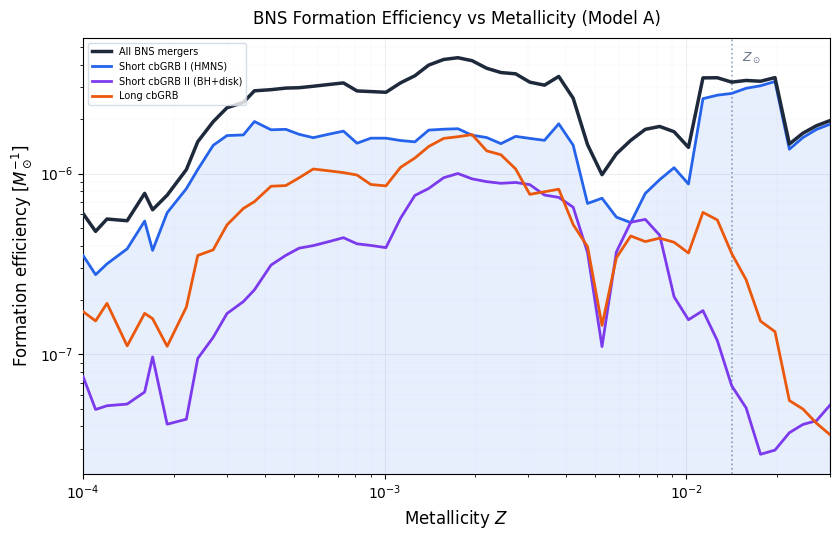

In [17]:
Z = np.array(metallicityGrid)
Z_solar = 0.0142

_safe = lambda arr: np.where(arr > 0, arr, np.nan)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.fill_between(Z, 0, _safe(eff_short_I), alpha=0.10, color='#2563EB', zorder=1)

ax.plot(Z, _safe(eff_total),    color='#1E293B', lw=2.5, label='All BNS mergers', zorder=4)
ax.plot(Z, _safe(eff_short_I),  color='#2563EB', lw=2,   label='Short cbGRB I (HMNS)', zorder=3)
ax.plot(Z, _safe(eff_short_II), color='#7C3AED', lw=2,   label='Short cbGRB II (BH+disk)', zorder=3)
ax.plot(Z, _safe(eff_long),     color='#EA580C', lw=2,   label='Long cbGRB', zorder=3)

ax.axvline(Z_solar, color='#94A3B8', lw=1.2, ls=':', zorder=0)
ax.text(Z_solar * 1.08, 0.97, r'$Z_\odot$', fontsize=9, color='#64748B',
        va='top', transform=ax.get_xaxis_transform())

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(Z[0], Z[-1])
ax.set_xlabel('Metallicity $Z$', fontsize=12)
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$', fontsize=12)
ax.set_title('BNS Formation Efficiency vs Metallicity (Model A)', fontsize=12, pad=10)

ax.grid(which='major', color='#E2E8F0', linewidth=0.5, linestyle='-', zorder=0)
ax.grid(which='minor', color='#F1F5F9', linewidth=0.3, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax.legend(fontsize=7, loc='upper left', frameon=True, fancybox=True,
          edgecolor='#CBD5E1')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_formation_efficiency.png',
            dpi=150, bbox_inches='tight')
plt.show()

### GRB Class Fraction vs Metallicity

Fraction of BNS mergers in each GRB class as a function of birth metallicity. The HMNS fraction (Short I) rises at high $Z$ because stronger wind mass-loss produces lighter NS remnants, shifting $M_\mathrm{tot}$ below $M_\mathrm{crit}$ (cf. Neijssel et al. 2019 Fig. 2). The dramatic swings near $Z \sim 0.005$ to $0.01$ are the same $\lambda$-bifurcation artifact noted in Section 4.

Max |short_I + short_II + long - 1| across metallicities: 2.22e-16


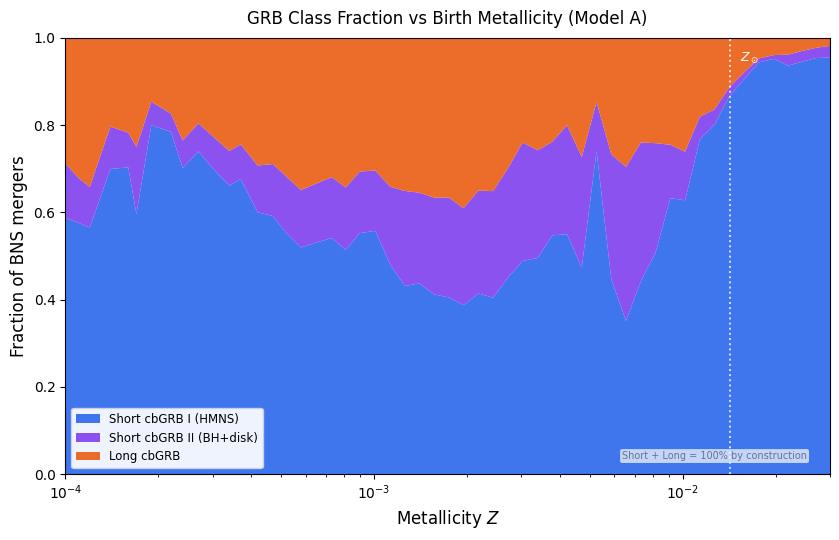

In [18]:
with np.errstate(invalid='ignore', divide='ignore'):
    denom        = eff_short + eff_long
    frac_short_I  = np.where(denom > 0, eff_short_I  / denom, np.nan)
    frac_short_II = np.where(denom > 0, eff_short_II / denom, np.nan)
    frac_long     = np.where(denom > 0, eff_long     / denom, np.nan)

valid = denom > 0
if valid.any():
    residual = np.abs(frac_short_I[valid] + frac_short_II[valid] + frac_long[valid] - 1.0).max()
    print(f"Max |short_I + short_II + long - 1| across metallicities: {residual:.2e}")

Z = np.array(metallicityGrid)
Z_solar = 0.0142

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.stackplot(Z, frac_short_I, frac_short_II, frac_long,
             colors=['#2563EB', '#7C3AED', '#EA580C'],
             labels=['Short cbGRB I (HMNS)', 'Short cbGRB II (BH+disk)', 'Long cbGRB'],
             alpha=0.88)

ax.axvline(Z_solar, color='white', lw=1.4, ls=':', alpha=0.8, zorder=5)
ax.text(Z_solar * 1.08, 0.97, r'$Z_\odot$', fontsize=9, color='white',
        fontweight='bold', va='top', transform=ax.get_xaxis_transform(), zorder=6)

ax.set_xscale('log')
ax.set_xlim(Z[valid][0], Z[valid][-1])
ax.set_ylim(0, 1.0)
ax.set_xlabel('Metallicity $Z$', fontsize=12)
ax.set_ylabel('Fraction of BNS mergers', fontsize=12)
ax.set_title('GRB Class Fraction vs Birth Metallicity (Model A)', fontsize=12, pad=10)

ax.legend(loc='lower left', fontsize=8.5, frameon=True, fancybox=True,
          edgecolor='#CBD5E1', framealpha=0.92)

ax.text(0.97, 0.03, 'Short + Long = 100% by construction',
        transform=ax.transAxes, fontsize=7, color='#64748B',
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='none', alpha=0.7))

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_grb_fraction_vs_metallicity.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Delay Time Distribution

Total delay time $t_\mathrm{delay} = t_\mathrm{form} + t_\mathrm{c}$ (stellar evolution + GW inspiral; Neijssel et al. 2019 eq. 1). The BNS delay time distribution is expected to be roughly $\propto t^{-1}$ (flat in $\log t$) from the Peters (1964) GW orbital decay formula, as confirmed by Neijssel et al. (2019) Fig. 3.

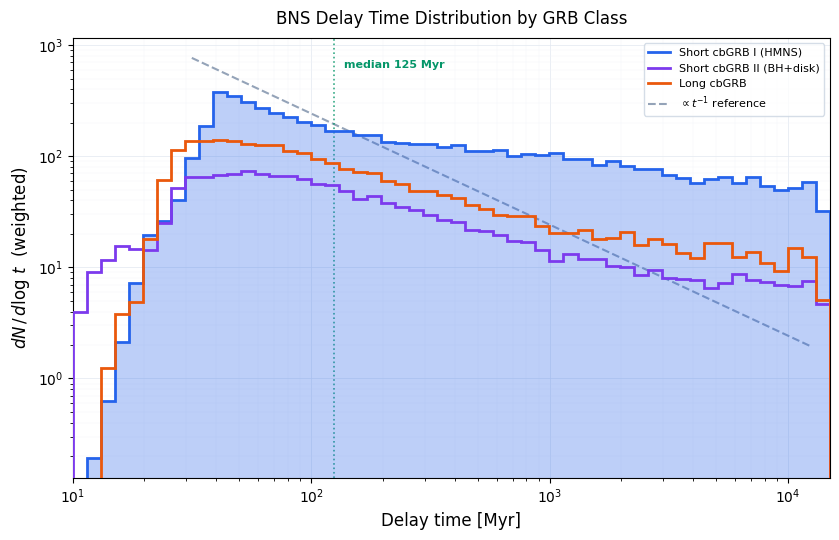

In [29]:
from matplotlib.lines import Line2D

delay_times = (tform + tc)[mask_merging]   # total delay time in Myr
w_m = weights[mask_merging]

t_short_I  = delay_times[short_typeI]
t_short_II = delay_times[short_typeII]
t_long     = delay_times[long_cbGRB]
w_short_I  = w_m[short_typeI]
w_short_II = w_m[short_typeII]
w_long     = w_m[long_cbGRB]

bins = np.logspace(1, np.log10(1.5e4), 55)   # 10 Myr to 15 Gyr

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.hist(t_short_I,  bins=bins, weights=w_short_I,
        histtype='stepfilled', color='#2563EB', alpha=0.30, zorder=2)
ax.hist(t_short_I,  bins=bins, weights=w_short_I,
        histtype='step', color='#2563EB', lw=2, zorder=3)

ax.hist(t_short_II, bins=bins, weights=w_short_II,
        histtype='step', color='#7C3AED', lw=2, zorder=3)
ax.hist(t_long,     bins=bins, weights=w_long,
        histtype='step', color='#EA580C', lw=2, zorder=3)

# t^{-1} reference (Peters 1964 prediction)
_tref = np.logspace(1.5, 4.1, 100)
_counts_total, _ = np.histogram(delay_times, bins=bins, weights=w_m)
_peak_idx = np.argmax(_counts_total)
_peak_val = _counts_total[_peak_idx]
_peak_t   = np.sqrt(bins[_peak_idx] * bins[_peak_idx + 1])
_ref_line = _peak_val * (_peak_t / _tref)
ax.plot(_tref, _ref_line, color='#94A3B8', lw=1.5, ls='--', zorder=1)

# Weighted median delay time
_sort_idx = np.argsort(delay_times)
_t_sorted = delay_times[_sort_idx]
_w_sorted = w_m[_sort_idx]
_cum_w = np.cumsum(_w_sorted)
_cum_w /= _cum_w[-1]
med_t = _t_sorted[np.searchsorted(_cum_w, 0.5)]
ax.axvline(med_t, color='#059669', lw=1.2, ls=':', alpha=0.8, zorder=1)
ax.text(med_t * 1.1, 0.95, f'median {med_t:.0f} Myr',
        fontsize=8, color='#059669', fontweight='bold', va='top',
        transform=ax.get_xaxis_transform())

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(10, 1.5e4)
ax.set_xlabel('Delay time [Myr]', fontsize=12)
ax.set_ylabel(r'$dN\,/\,d\log\,t$  (weighted)', fontsize=12)
ax.set_title('BNS Delay Time Distribution by GRB Class', fontsize=12, pad=10)

ax.grid(which='major', color='#E2E8F0', linewidth=0.5, linestyle='-', zorder=0)
ax.grid(which='minor', color='#F1F5F9', linewidth=0.3, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax.legend(handles=[
    Line2D([0],[0], color='#2563EB', lw=2, label='Short cbGRB I (HMNS)'),
    Line2D([0],[0], color='#7C3AED', lw=2, label='Short cbGRB II (BH+disk)'),
    Line2D([0],[0], color='#EA580C', lw=2, label='Long cbGRB'),
    Line2D([0],[0], color='#94A3B8', lw=1.5, ls='--', label=r'$\propto t^{-1}$ reference'),
], fontsize=8, loc='upper right', frameon=True, fancybox=True,
   edgecolor='#CBD5E1')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_delay_time_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 5. Model Comparison: A vs K

Model K ("optimistic CE") assumes that Hertzsprung Gap donor stars initiating a common envelope phase survive, whereas Model A (fiducial) treats them pessimistically. Comparing the formation efficiencies of each GRB class across both models tests whether the classification results are robust to this key binary evolution uncertainty (Broekgaarden et al. 2022, Table 1).

In [30]:
path_K = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_K.h5'

fdata_K = h5.File(path_K, 'r')
fDCO_K  = fdata_K['doubleCompactObjects']

mass1_K              = fDCO_K['M1'][...].squeeze()
mass2_K              = fDCO_K['M2'][...].squeeze()
weights_K            = fDCO_K['weight'][...].squeeze()
metallicity_K        = fDCO_K['Metallicity1'][...].squeeze()
merges_K             = fDCO_K['mergesInHubbleTimeFlag'][...].squeeze()
tc_K                 = fDCO_K['tc'][...].squeeze()
tform_K              = fDCO_K['tform'][...].squeeze()

mask_K   = (merges_K == 1)
M_tot_K  = mass1_K[mask_K] + mass2_K[mask_K]
q_K      = np.maximum(mass1_K[mask_K], mass2_K[mask_K]) / \
           np.minimum(mass1_K[mask_K], mass2_K[mask_K])

short_K  = (M_tot_K < M_crit) | ((M_tot_K >= M_crit) & (q_K < 1.2))
long_K   = (M_tot_K >= M_crit) & (q_K >= 1.2)

print(f"Model K - Short cbGRB: {short_K.sum():,} ({100*short_K.sum()/mask_K.sum():.1f}%)")
print(f"Model K - Long cbGRB:  {long_K.sum():,}  ({100*long_K.sum()/mask_K.sum():.1f}%)")

Model K - Short cbGRB: 191,290 (81.4%)
Model K - Long cbGRB:  43,673  (18.6%)


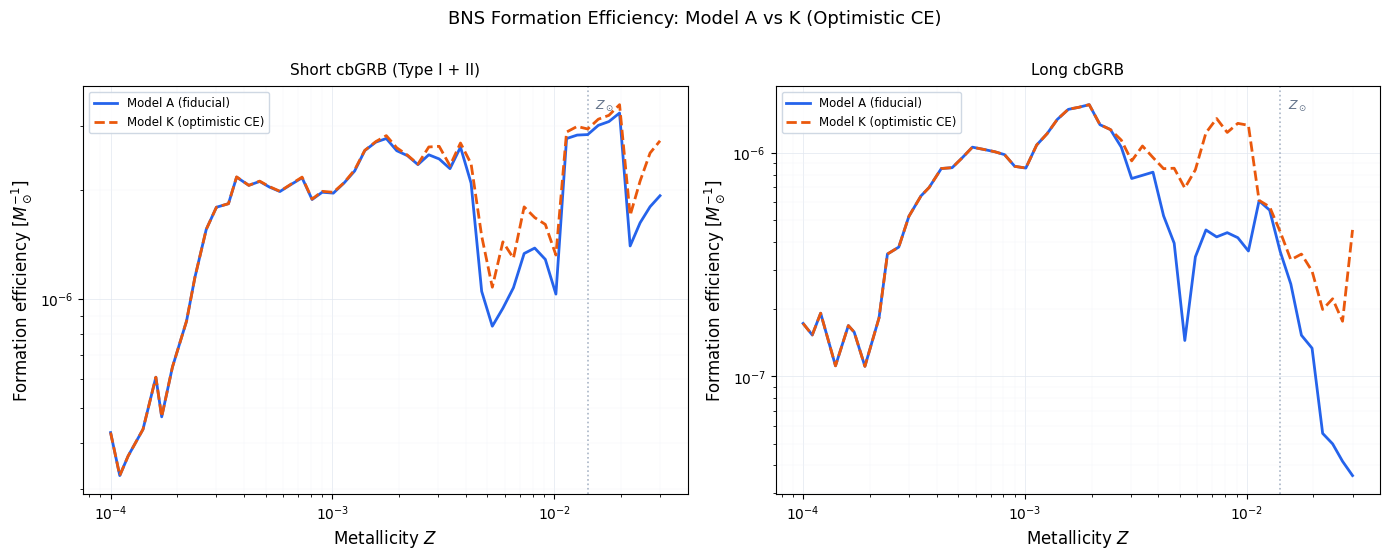

In [31]:
Z_K = metallicity_K[mask_K]
w_K = weights_K[mask_K]
unique_ZK = np.unique(metallicity_K)

eff_total_K = np.zeros(len(metallicityGrid))
eff_short_K = np.zeros(len(metallicityGrid))
eff_long_K  = np.zeros(len(metallicityGrid))

for i, Z in enumerate(metallicityGrid):
    if Z in unique_ZK:
        maskZ = (Z_K == Z)
        eff_total_K[i] = np.sum(w_K[maskZ])               / meanMassEvolved
        eff_short_K[i] = np.sum(w_K[maskZ & short_K])     / meanMassEvolved
        eff_long_K[i]  = np.sum(w_K[maskZ & long_K])      / meanMassEvolved

_safe = lambda arr: np.where(np.array(arr) > 0, arr, np.nan)
Z = np.array(metallicityGrid)
Z_solar = 0.0142

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('BNS Formation Efficiency: Model A vs K (Optimistic CE)', fontsize=13, y=1.01)

for ax, eff_A, eff_B, title in [
    (axes[0], eff_short, eff_short_K, 'Short cbGRB (Type I + II)'),
    (axes[1], eff_long,  eff_long_K,  'Long cbGRB')
]:
    ax.plot(Z, _safe(eff_A), color='#2563EB', lw=2, label='Model A (fiducial)', zorder=3)
    ax.plot(Z, _safe(eff_B), color='#EA580C', lw=2, ls='--', label='Model K (optimistic CE)', zorder=3)

    ax.axvline(Z_solar, color='#94A3B8', lw=1.2, ls=':', alpha=0.8, zorder=2)
    ax.text(Z_solar * 1.08, 0.97, r'$Z_\odot$', fontsize=9, color='#64748B',
            fontweight='bold', va='top', transform=ax.get_xaxis_transform(), zorder=4)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Metallicity $Z$', fontsize=12)
    ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$', fontsize=12)
    ax.set_title(title, fontsize=11, pad=8)

    ax.grid(which='major', color='#E2E8F0', linewidth=0.5, linestyle='-', zorder=0)
    ax.grid(which='minor', color='#F1F5F9', linewidth=0.3, linestyle='-', zorder=0)
    ax.set_axisbelow(True)

    ax.legend(fontsize=8.5, loc='upper left', frameon=True, fancybox=True,
              edgecolor='#CBD5E1', framealpha=0.92)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_model_ak_efficiency.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Uncertainty Analysis

Sensitivity of the GRB class fractions to the two free classification parameters.

### 6a. M_crit Sensitivity (NS Equation of State)

Vary the critical total mass $M_{\rm crit}$ from 2.5 to 3.1 $M_\odot$ to probe EOS uncertainty.

**EOS-specific $M_{\rm crit}$ values** (threshold total mass for prompt collapse to BH, from Bauswein et al. 2013 [arXiv:1307.5191] and Hotokezaka et al. 2011 [arXiv:1105.4370]):

| EOS | $M_{\rm crit}\,[M_\odot]$ | $R_{1.4}\,[\mathrm{km}]$ |
|-----|:---:|:---:|
| APR4 | 2.53 | ~11.1 |
| SFHo | 2.60 | ~11.9 |
| LS220 | 2.72 | ~12.7 |
| DD2 | 3.06 | ~13.2 |

The secondary $R_{1.4}$ axis uses a linear interpolation between SFHo and DD2 for visualization only; the true $M_{\rm crit}(R_{1.4})$ relation is non-linear and EOS-dependent.

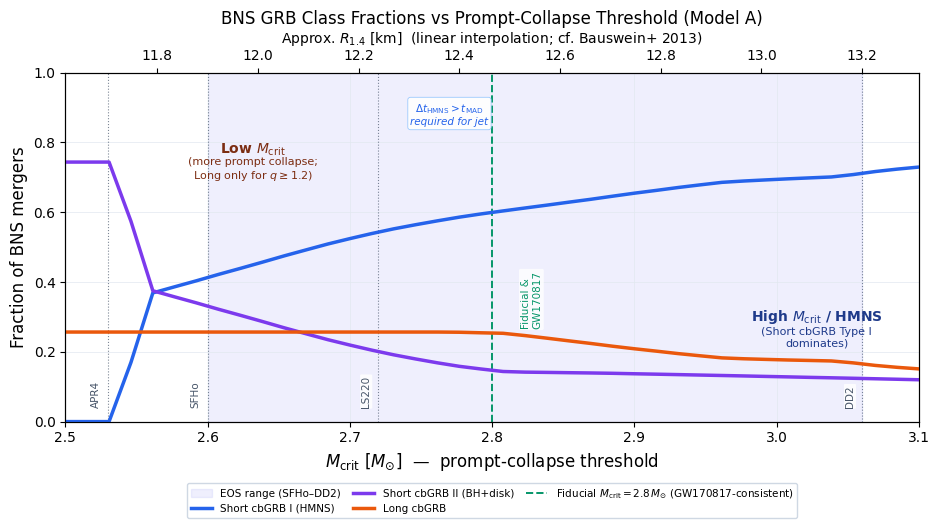

In [35]:
M_crit_range = np.linspace(2.5, 3.1, 40)
frac_long_vs_Mcrit     = []
frac_short_I_vs_Mcrit  = []
frac_short_II_vs_Mcrit = []

w_tot = np.sum(w_all)
for Mc in M_crit_range:
    s_I = (M_tot < Mc)
    s_II = (M_tot >= Mc) & (q < 1.2)
    l   = (M_tot >= Mc) & (q >= 1.2)
    frac_short_I_vs_Mcrit.append(np.sum(w_all[s_I]) / w_tot)
    frac_short_II_vs_Mcrit.append(np.sum(w_all[s_II]) / w_tot)
    frac_long_vs_Mcrit.append(np.sum(w_all[l]) / w_tot)

def mcrit_to_r14(mc):
    return 11.9 + (13.2 - 11.9) / (3.06 - 2.60) * (mc - 2.60)

eos_models = {'APR4': 2.53, 'SFHo': 2.60, 'LS220': 2.72, 'DD2': 3.06}

fig, ax = plt.subplots(figsize=(9.5, 5.5))

ax.axvspan(2.60, 3.06, alpha=0.10, color='#6366F1', zorder=0,
           label='EOS range (SFHo\u2013DD2)')

ax.plot(M_crit_range, frac_short_I_vs_Mcrit,
        color='#2563EB', lw=2.5, label='Short cbGRB I (HMNS)', zorder=3)
ax.plot(M_crit_range, frac_short_II_vs_Mcrit,
        color='#7C3AED', lw=2.5, label='Short cbGRB II (BH+disk)', zorder=3)
ax.plot(M_crit_range, frac_long_vs_Mcrit,
        color='#EA580C', lw=2.5, label='Long cbGRB', zorder=3)

ax.axvline(2.8, color='#059669', ls='--', lw=1.4, zorder=2,
           label='Fiducial $M_{\\mathrm{crit}} = 2.8\\,M_{\\odot}$ (GW170817-consistent)')
ax.text(2.82, 0.35, 'Fiducial &\nGW170817', rotation=90,
        fontsize=7.5, color='#059669', va='center', ha='left',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                  edgecolor='none', alpha=0.8))

for name, mc in eos_models.items():
    if M_crit_range[0] <= mc <= M_crit_range[-1]:
        ax.axvline(mc, color='#475569', lw=0.8, ls=':', alpha=0.7, zorder=1)
        ax.text(mc - 0.005, 0.04, name, rotation=90, fontsize=7.5,
                color='#475569', ha='right', va='bottom',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor='none', alpha=0.85))

ax.text(0.22, 0.78, 'Low $M_{\\mathrm{crit}}$', fontsize=10, transform=ax.transAxes,
        color='#7C2D12', ha='center', va='center', fontweight='bold')
ax.text(0.22, 0.72, '(more prompt collapse;\nLong only for $q \\geq 1.2$)', fontsize=8,
        transform=ax.transAxes, color='#7C2D12', ha='center', va='center')

ax.text(0.88, 0.30, 'High $M_{\\mathrm{crit}}$ / HMNS', fontsize=10, transform=ax.transAxes,
        color='#1E3A8A', ha='center', va='center', fontweight='bold')
ax.text(0.88, 0.24, '(Short cbGRB Type I\ndominates)', fontsize=8,
        transform=ax.transAxes, color='#1E3A8A', ha='center', va='center')

ax.text(0.45, 0.88, '$\\Delta t_{\\rm HMNS} > t_{\\rm MAD}$\nrequired for jet',
        transform=ax.transAxes,
        fontsize=7.5, color='#2563EB', ha='center', va='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='#93C5FD', alpha=0.9, lw=0.6))

ax.legend(fontsize=7.5, loc='upper center', ncol=3,
          bbox_to_anchor=(0.5, -0.16),
          frameon=True, framealpha=0.92, fancybox=True, edgecolor='#CBD5E1',
          columnspacing=1.2)

ax.set_xlim(M_crit_range[0], M_crit_range[-1])
ax.set_ylim(0, 1)
ax.set_xlabel(
    '$M_{\\mathrm{crit}}$ [$M_{\\odot}$]  \u2014  prompt-collapse threshold',
    fontsize=12)
ax.set_ylabel('Fraction of BNS mergers', fontsize=12)
ax.set_title('BNS GRB Class Fractions vs Prompt-Collapse Threshold (Model A)',
             fontsize=12, pad=35)

ax.grid(which='major', color='#E2E8F0', linewidth=0.5, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax2 = ax.twiny()
ax2.set_xlim(mcrit_to_r14(M_crit_range[0]), mcrit_to_r14(M_crit_range[-1]))
ax2.set_xlabel(
    r'Approx. $R_{1.4}$ [km]  (linear interpolation; cf. Bauswein+ 2013)',
    fontsize=10)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_mcrit_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 6b. Mass Ratio Threshold Sensitivity

Vary the $q$ threshold that separates Short cbGRB II from Long cbGRB among prompt-collapse systems ($M_\mathrm{tot} \geq M_\mathrm{crit}$). The fiducial value $q_\mathrm{thresh} = 1.2$ is from Gottlieb et al. (2023). Short cbGRB I (HMNS, $M_\mathrm{tot} < M_\mathrm{crit}$) is independent of $q_\mathrm{thresh}$ by construction.

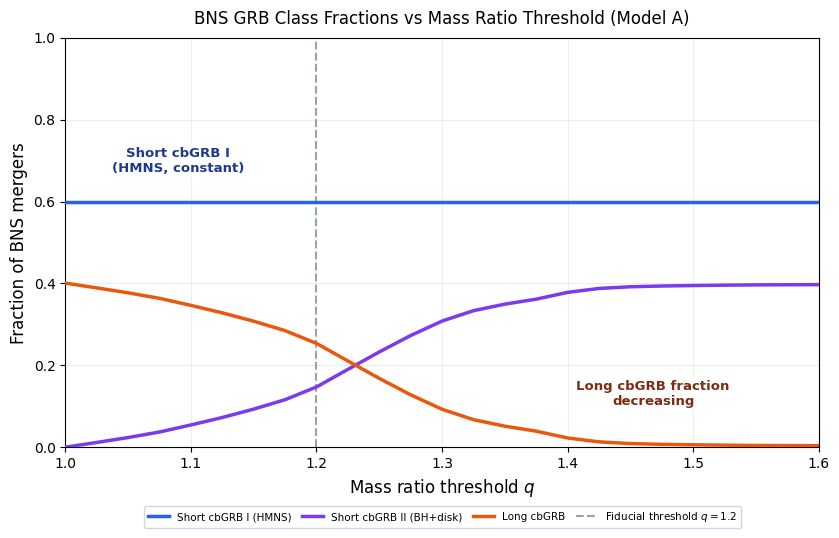

In [36]:
q_thresh_range = np.linspace(1.0, 1.6, 25)
frac_short_I_q  = []
frac_short_II_q = []
frac_long_q     = []

w_tot = np.sum(w_all)
for qt in q_thresh_range:
    s_I  = (M_tot < M_crit)
    s_II = (M_tot >= M_crit) & (q < qt)
    l    = (M_tot >= M_crit) & (q >= qt)
    frac_short_I_q.append(np.sum(w_all[s_I]) / w_tot)
    frac_short_II_q.append(np.sum(w_all[s_II]) / w_tot)
    frac_long_q.append(np.sum(w_all[l]) / w_tot)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.plot(q_thresh_range, frac_short_I_q,  color='#2563EB', lw=2.5,
        label='Short cbGRB I (HMNS)', zorder=3)
ax.plot(q_thresh_range, frac_short_II_q, color='#7C3AED', lw=2.5,
        label='Short cbGRB II (BH+disk)', zorder=3)
ax.plot(q_thresh_range, frac_long_q,     color='#EA580C', lw=2.5,
        label='Long cbGRB', zorder=3)
ax.axvline(1.2, color='#94A3B8', ls='--', lw=1.5, zorder=2,
           label='Fiducial threshold $q = 1.2$')

ax.text(0.15, 0.70, 'Short cbGRB I\n(HMNS, constant)', fontsize=9.5,
        transform=ax.transAxes, color='#1E3A8A', ha='center', va='center',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='none', alpha=0.85))

ax.text(0.78, 0.13, 'Long cbGRB fraction\ndecreasing', fontsize=9.5,
        transform=ax.transAxes, color='#7C2D12', ha='center', va='center',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='none', alpha=0.85))

ax.set_xlim(q_thresh_range[0], q_thresh_range[-1])
ax.set_ylim(0, 1.0)
ax.set_xlabel('Mass ratio threshold $q$', fontsize=12)
ax.set_ylabel('Fraction of BNS mergers', fontsize=12)
ax.set_title('BNS GRB Class Fractions vs Mass Ratio Threshold (Model A)',
             fontsize=12, pad=10)

ax.grid(which='major', color='#E2E8F0', linewidth=0.5, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax.legend(fontsize=7.5, loc='upper center', ncol=4,
          bbox_to_anchor=(0.5, -0.13),
          frameon=True, framealpha=0.92, fancybox=True, edgecolor='#CBD5E1',
          columnspacing=1.0)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_q_threshold_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 6c. Mass Ratio Distribution

Weighted histogram of the NS mass ratio $q = M_\mathrm{max}/M_\mathrm{min}$ for each GRB class. The strong spike at $q \approx 1.0$ is driven by the ECSN floor, which produces a pile-up of neutron stars at a fixed mass of $1.26\,M_\odot$ (Vigna-Gomez et al. 2018). The y-axis is truncated to reveal the body of the distribution; the true peak value is annotated.

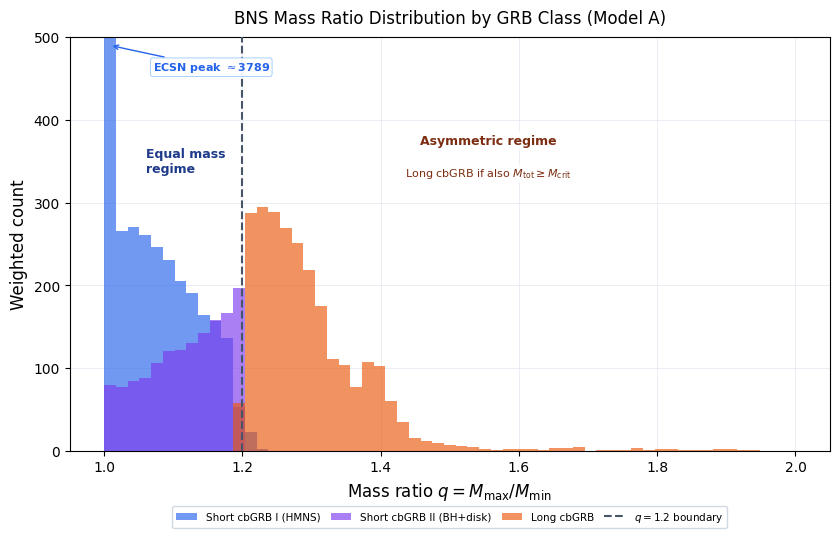

In [40]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
bins = np.linspace(1.0, 2.0, 60)

w_merg = weights[mask_merging]

ax.hist(q[short_typeI], bins=bins, weights=w_merg[short_typeI],
        color='#2563EB', alpha=0.65, label='Short cbGRB I (HMNS)', zorder=2)
ax.hist(q[short_typeII], bins=bins, weights=w_merg[short_typeII],
        color='#7C3AED', alpha=0.65, label='Short cbGRB II (BH+disk)', zorder=2)
ax.hist(q[long_cbGRB],  bins=bins, weights=w_merg[long_cbGRB],
        color='#EA580C', alpha=0.65, label='Long cbGRB', zorder=2)
ax.axvline(1.2, color='#475569', ls='--', lw=1.5, zorder=3,
           label='$q = 1.2$ boundary')

_peak_counts, _ = np.histogram(q[short_typeI], bins=bins, weights=w_merg[short_typeI])
_peak_val = _peak_counts.max()

y_cut = 500
ax.set_ylim(0, y_cut)
ax.annotate(f'ECSN peak $\\approx${_peak_val:.0f}',
            xy=(1.008, y_cut * 0.98), xytext=(1.07, y_cut * 0.92),
            fontsize=8, color='#2563EB', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2563EB', lw=1.0),
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='#93C5FD', alpha=0.95, lw=0.6),
            zorder=5)

ax.text(0.10, 0.70, 'Equal mass\nregime', fontsize=9, transform=ax.transAxes,
        color='#1E3A8A', ha='left', va='center', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='none', alpha=0.95))

ax.text(0.55, 0.75, 'Asymmetric regime', fontsize=9, transform=ax.transAxes,
        color='#7C2D12', ha='center', va='center', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='none', alpha=0.85))
ax.text(0.55, 0.67, 'Long cbGRB if also $M_{\\rm tot} \\geq M_{\\rm crit}$',
        fontsize=8, transform=ax.transAxes, color='#7C2D12',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='none', alpha=0.85))

ax.set_xlabel('Mass ratio $q = M_{\\rm max}/M_{\\rm min}$', fontsize=12)
ax.set_ylabel('Weighted count', fontsize=12)
ax.set_title('BNS Mass Ratio Distribution by GRB Class (Model A)',
             fontsize=12, pad=10)

ax.grid(which='major', color='#E2E8F0', linewidth=0.5, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax.legend(fontsize=7.5, loc='upper center', ncol=4,
          bbox_to_anchor=(0.5, -0.12),
          frameon=True, framealpha=0.92, fancybox=True, edgecolor='#CBD5E1',
          columnspacing=1.0)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_mass_ratio_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 6d. Progenitor ZAMS Mass Plane

Which zero-age main sequence stellar systems produce each GRB class?

Note: the median ZAMS mass ratio ($M_{1,\mathrm{ZAMS}}/M_{2,\mathrm{ZAMS}}$) for Long cbGRB progenitors is only ~1.02, meaning most Long cbGRBs arise from nearly equal-ZAMS systems where binary evolution (mass transfer, stripping) creates the final NS mass asymmetry ($q \geq 1.2$). The visible "cloud" of orange points well below the diagonal represents a real but minority subset where initial mass asymmetry directly drives the final $q$.

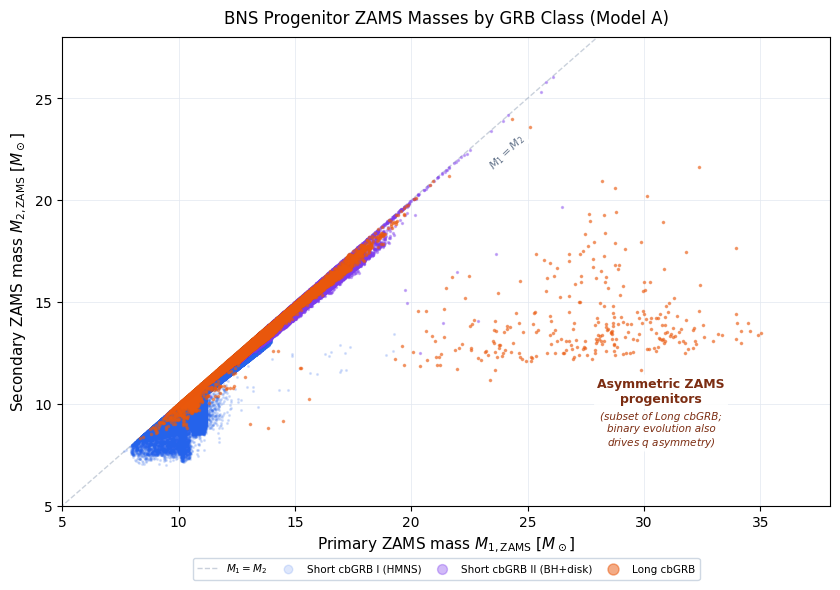

In [41]:
m1zams_merging = m1zams[mask_merging]
m2zams_merging = m2zams[mask_merging]

fig, ax = plt.subplots(figsize=(8.5, 6))

ax.plot([0, 80], [0, 80], color='#94A3B8', ls='--', lw=1, alpha=0.5,
        label='$M_1 = M_2$', zorder=1)
ax.scatter(m1zams_merging[short_typeI],  m2zams_merging[short_typeI],
           s=1.5, alpha=0.15, color='#2563EB', label='Short cbGRB I (HMNS)',
           rasterized=True, zorder=2)
ax.scatter(m1zams_merging[short_typeII], m2zams_merging[short_typeII],
           s=2.0, alpha=0.35, color='#7C3AED', label='Short cbGRB II (BH+disk)',
           rasterized=True, zorder=3)
ax.scatter(m1zams_merging[long_cbGRB],  m2zams_merging[long_cbGRB],
           s=2.5, alpha=0.5,  color='#EA580C', label='Long cbGRB',
           rasterized=True, zorder=4)

ax.set_xlim(5, 38)
ax.set_ylim(5, 28)

ax.text(0.58, 0.72, '$M_1 = M_2$', fontsize=8, transform=ax.transAxes,
        color='#64748B', fontweight='bold', rotation=44, ha='center',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                  edgecolor='none', alpha=0.9))

ax.text(0.78, 0.22, 'Asymmetric ZAMS\nprogenitors', fontsize=9,
        transform=ax.transAxes, color='#7C2D12', fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='none', alpha=0.9))
ax.text(0.78, 0.13, '(subset of Long cbGRB;\nbinary evolution also\ndrives $q$ asymmetry)',
        fontsize=7.5, transform=ax.transAxes, color='#7C2D12', ha='center',
        style='italic',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='none', alpha=0.9))

ax.set_xlabel(r'Primary ZAMS mass $M_{1,\rm ZAMS}$ [$M_\odot$]', fontsize=11)
ax.set_ylabel(r'Secondary ZAMS mass $M_{2,\rm ZAMS}$ [$M_\odot$]', fontsize=11)
ax.set_title('BNS Progenitor ZAMS Masses by GRB Class (Model A)',
             fontsize=12, pad=10)

ax.grid(which='major', color='#E2E8F0', linewidth=0.5, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax.legend(markerscale=5, fontsize=7.5, loc='upper center', ncol=4,
          bbox_to_anchor=(0.5, -0.10),
          frameon=True, framealpha=0.92, fancybox=True, edgecolor='#CBD5E1',
          columnspacing=1.0)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_progenitor_zams_plane.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Export

Save formation efficiency arrays for use in the comparison notebook.

In [42]:
import numpy as np
np.save('/Users/josephrodriguez/research visualization/results/eff_BNS.npy', 
        np.array([eff_total, eff_short, eff_long]))
print("BNS efficiencies saved.")

BNS efficiencies saved.
